# Stepwise Regression with Joint VIF and P-Value Stopping Criterion

**Author:** Abdulrahman Hussein  
**Supervisor:** Dr. Joseph D. Ortiz  
**Institution:** Kent State University, Department of Earth Sciences

---

## Overview

This notebook implements a comprehensive stepwise regression algorithm that combines:
1. **P-value criterion** (F-test) for statistical significance
2. **VIF (Variance Inflation Factor)** for multicollinearity detection

The algorithm stops when BOTH criteria are satisfied:
- All variables in the model have p-value < threshold (statistically significant)
- All variables in the model have VIF < threshold (no multicollinearity)

### Features
- **Three selection methods:** Forward, Backward, Bidirectional
- **Multiple criteria:** P-values, AIC, BIC, Adjusted R²
- **VIF-based multicollinearity handling**
- **Early stopping** with patience and tolerance
- **Categorical variable handling** with automatic dummy encoding
- **Visualization** of selection process
- **Detailed logging** of iterations
- **Scikit-learn style API**

## 1. Import Libraries

In [5]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from typing import List, Tuple, Optional, Union, Dict
from dataclasses import dataclass, field

warnings.filterwarnings('ignore')

# Try to use seaborn style, fallback to default if not available
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    try:
        plt.style.use('seaborn-whitegrid')
    except:
        plt.style.use('default')

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. VIF Calculation Functions

In [ ]:
def calculate_vif(X: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate Variance Inflation Factor for all features in X.
    
    VIF = 1 / (1 - R²) where R² is from regressing each feature against all others.
    
    Parameters
    ----------
    X : pd.DataFrame
        DataFrame containing only the predictor variables (no intercept)
    
    Returns
    -------
    pd.DataFrame
        DataFrame with columns ['feature', 'VIF']
    """
    if X.shape[1] < 2:
        return pd.DataFrame({'feature': X.columns, 'VIF': [1.0] * X.shape[1]})
    
    vif_data = pd.DataFrame()
    vif_data['feature'] = X.columns
    
    vif_values = []
    for i in range(X.shape[1]):
        try:
            vif = variance_inflation_factor(X.values, i)
            vif_values.append(vif)
        except (np.linalg.LinAlgError, ValueError):
            vif_values.append(np.inf)
    
    vif_data['VIF'] = vif_values
    return vif_data


def calculate_vif_manual(X: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate VIF manually using the R² method.
    
    For each feature Xi, regress it against all other features and compute:
    VIF_i = 1 / (1 - R²_i)
    
    Parameters
    ----------
    X : pd.DataFrame
        DataFrame containing predictor variables
    
    Returns
    -------
    pd.DataFrame
        DataFrame with columns ['feature', 'VIF', 'R2']
    """
    if X.shape[1] < 2:
        return pd.DataFrame({'feature': X.columns, 'VIF': [1.0], 'R2': [0.0]})
    
    vif_list = []
    columns = X.columns.tolist()
    
    for col in columns:
        other_cols = [c for c in columns if c != col]
        y_temp = X[col].values
        X_temp = sm.add_constant(X[other_cols].values)
        
        try:
            model = sm.OLS(y_temp, X_temp).fit()
            r2 = model.rsquared
            vif = 1.0 / (1.0 - r2) if r2 < 1.0 else np.inf
        except (np.linalg.LinAlgError, ValueError):
            r2 = np.nan
            vif = np.inf
        
        vif_list.append({'feature': col, 'VIF': vif, 'R2': r2})
    
    return pd.DataFrame(vif_list)


print("VIF functions defined.")

VIF functions defined.


In [ ]:
# 3. Stepwise Selection Helper Functions

def fit_ols_model(X: pd.DataFrame, y: pd.Series, add_const: bool = True) -> sm.regression.linear_model.RegressionResultsWrapper:
    """
    Fit an OLS model and return the results.
    
    Parameters
    ----------
    X : pd.DataFrame
        Predictor variables
    y : pd.Series
        Response variable
    add_const : bool
        Whether to add a constant (intercept) to the model
    
    Returns
    -------
    statsmodels RegressionResultsWrapper
    """
    if add_const:
        X_with_const = sm.add_constant(X, has_constant='add')
    else:
        X_with_const = X
    
    model = sm.OLS(y, X_with_const).fit()
    return model


def get_model_metrics(model) -> Dict:
    """
    Extract key metrics from a fitted OLS model.
    
    Returns
    -------
    dict
        Dictionary containing R², Adjusted R², AIC, BIC, F-statistic, F p-value
    """
    return {
        'r2': model.rsquared,
        'adj_r2': model.rsquared_adj,
        'aic': model.aic,
        'bic': model.bic,
        'f_statistic': model.fvalue,
        'f_pvalue': model.f_pvalue,
        'n_obs': int(model.nobs),
        'df_model': int(model.df_model),
        'df_resid': int(model.df_resid)
    }


def check_vif_threshold(X: pd.DataFrame, threshold: float = 5.0) -> Tuple[bool, pd.DataFrame]:
    """
    Check if all VIF values are below the threshold.
    
    Parameters
    ----------
    X : pd.DataFrame
        Predictor variables currently in the model
    threshold : float
        Maximum acceptable VIF value
    
    Returns
    -------
    Tuple[bool, pd.DataFrame]
        (all_below_threshold, vif_dataframe)
    """
    if X.shape[1] == 0:
        return True, pd.DataFrame()
    
    vif_df = calculate_vif(X)
    all_below = (vif_df['VIF'] < threshold).all()
    return all_below, vif_df


def get_highest_vif_variable(X: pd.DataFrame) -> Tuple[str, float]:
    """
    Find the variable with the highest VIF.
    
    Returns
    -------
    Tuple[str, float]
        (variable_name, vif_value)
    """
    vif_df = calculate_vif(X)
    idx = vif_df['VIF'].idxmax()
    return vif_df.loc[idx, 'feature'], vif_df.loc[idx, 'VIF']


def handle_categorical_variables(X: pd.DataFrame, categorical_cols: List[str] = None, 
                                  drop_first: bool = True) -> Tuple[pd.DataFrame, Dict]:
    """
    Handle categorical variables by converting them to dummy variables.
    
    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix
    categorical_cols : List[str], optional
        List of categorical column names. If None, auto-detect object/category columns.
    drop_first : bool
        Whether to drop the first dummy column to avoid multicollinearity
    
    Returns
    -------
    Tuple[pd.DataFrame, Dict]
        (transformed_dataframe, mapping_dict)
        mapping_dict contains info about which columns were encoded
    """
    X_transformed = X.copy()
    mapping = {'original_categoricals': [], 'dummy_columns': {}}
    
    # Auto-detect categorical columns if not specified
    if categorical_cols is None:
        categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    
    if not categorical_cols:
        return X_transformed, mapping
    
    mapping['original_categoricals'] = categorical_cols
    
    for col in categorical_cols:
        if col in X_transformed.columns:
            # Create dummy variables
            dummies = pd.get_dummies(X_transformed[col], prefix=col, drop_first=drop_first)
            mapping['dummy_columns'][col] = dummies.columns.tolist()
            
            # Drop original and add dummies
            X_transformed = X_transformed.drop(columns=[col])
            X_transformed = pd.concat([X_transformed, dummies], axis=1)
    
    print(f"Categorical variables encoded: {categorical_cols}")
    print(f"New dummy columns created: {sum(len(v) for v in mapping['dummy_columns'].values())}")
    
    return X_transformed, mapping


print("Helper functions defined (including categorical variable handling).")

Helper functions defined.


In [8]:
## 4. Iteration Log Data Class

@dataclass
class IterationLog:
    """
    Data class to store information about each iteration of stepwise selection.
    """
    step: int
    action: str  # 'add', 'remove', 'vif_remove'
    variable: str
    p_value: float
    vif: float
    r2: float
    adj_r2: float
    aic: float
    bic: float
    variables_in_model: List[str]
    
    def to_dict(self) -> Dict:
        return {
            'step': self.step,
            'action': self.action,
            'variable': self.variable,
            'p_value': self.p_value,
            'vif': self.vif,
            'r2': self.r2,
            'adj_r2': self.adj_r2,
            'aic': self.aic,
            'bic': self.bic,
            'n_variables': len(self.variables_in_model),
            'variables': ', '.join(self.variables_in_model)
        }

print("IterationLog class defined.")

IterationLog class defined.


## 5. Main StepwiseVIFRegression Class

This is the core class that implements stepwise regression with joint VIF and p-value stopping criterion.

In [9]:
class StepwiseVIFRegression:
    """
    Stepwise Regression with Joint VIF and P-Value Stopping Criterion.
    
    This class implements forward, backward, and bidirectional stepwise regression
    with a joint stopping criterion based on both statistical significance (p-values)
    and multicollinearity (VIF).
    
    Parameters
    ----------
    method : str, default='bidirectional'
        Selection method: 'forward', 'backward', or 'bidirectional'
    p_enter : float, default=0.05
        P-value threshold for adding a variable (forward/bidirectional)
    p_remove : float, default=0.10
        P-value threshold for removing a variable (backward/bidirectional)
    vif_threshold : float, default=5.0
        Maximum acceptable VIF value. Variables with VIF > threshold will be removed.
    criteria : str, default='pvalue'
        Selection criteria: 'pvalue', 'aic', 'bic', or 'adjr2'
    max_iter : int, default=100
        Maximum number of iterations
    early_stopping : bool, default=False
        Whether to use early stopping based on model improvement
    patience : int, default=5
        Number of iterations without improvement before stopping (if early_stopping=True)
    tolerance : float, default=0.001
        Minimum improvement required (if early_stopping=True)
    verbose : int, default=1
        Verbosity level: 0=silent, 1=progress, 2=detailed
    
    Attributes
    ----------
    selected_features_ : list
        List of selected feature names after fitting
    model_ : statsmodels RegressionResultsWrapper
        The final fitted OLS model
    iteration_history_ : list
        List of IterationLog objects for each step
    vif_final_ : pd.DataFrame
        VIF values for the final selected features
    """
    
    def __init__(
        self,
        method: str = 'bidirectional',
        p_enter: float = 0.05,
        p_remove: float = 0.10,
        vif_threshold: float = 5.0,
        criteria: str = 'pvalue',
        max_iter: int = 100,
        early_stopping: bool = False,
        patience: int = 5,
        tolerance: float = 0.001,
        verbose: int = 1
    ):
        self.method = method.lower()
        self.p_enter = p_enter
        self.p_remove = p_remove
        self.vif_threshold = vif_threshold
        self.criteria = criteria.lower()
        self.max_iter = max_iter
        self.early_stopping = early_stopping
        self.patience = patience
        self.tolerance = tolerance
        self.verbose = verbose
        
        # Attributes set during fit
        self.selected_features_: List[str] = []
        self.model_ = None
        self.iteration_history_: List[IterationLog] = []
        self.vif_final_: Optional[pd.DataFrame] = None
        self.feature_names_: List[str] = []
        self._is_fitted = False
    
    def _print(self, message: str, level: int = 1):
        """Print message if verbosity level is sufficient."""
        if self.verbose >= level:
            print(message)
    
    def _validate_inputs(self, X: pd.DataFrame, y: pd.Series):
        """Validate input data."""
        if not isinstance(X, pd.DataFrame):
            raise ValueError("X must be a pandas DataFrame")
        if not isinstance(y, (pd.Series, np.ndarray)):
            raise ValueError("y must be a pandas Series or numpy array")
        if len(X) != len(y):
            raise ValueError("X and y must have the same number of samples")
        if X.isnull().any().any():
            raise ValueError("X contains missing values")
        if pd.Series(y).isnull().any():
            raise ValueError("y contains missing values")
    
    def _get_candidate_pvalues(self, X: pd.DataFrame, y: pd.Series, 
                                current_features: List[str], 
                                candidate_features: List[str]) -> pd.DataFrame:
        """
        Calculate p-values for each candidate feature if added to the model.
        """
        results = []
        
        for candidate in candidate_features:
            test_features = current_features + [candidate]
            try:
                model = fit_ols_model(X[test_features], y)
                # Get p-value for the candidate variable (last one added)
                p_val = model.pvalues[candidate]
                metrics = get_model_metrics(model)
                results.append({
                    'feature': candidate,
                    'pvalue': p_val,
                    'aic': metrics['aic'],
                    'bic': metrics['bic'],
                    'adj_r2': metrics['adj_r2']
                })
            except Exception as e:
                self._print(f"  Warning: Could not fit model with {candidate}: {e}", 2)
                continue
        
        return pd.DataFrame(results)
    
    def _remove_high_vif_variables(self, X: pd.DataFrame, y: pd.Series,
                                    current_features: List[str], step: int) -> Tuple[List[str], int]:
        """
        Iteratively remove variables with VIF > threshold.
        """
        features = current_features.copy()
        
        while len(features) > 1:
            vif_ok, vif_df = check_vif_threshold(X[features], self.vif_threshold)
            
            if vif_ok:
                break
            
            # Find and remove the variable with highest VIF
            var_to_remove, max_vif = get_highest_vif_variable(X[features])
            
            self._print(f"  VIF Removal: {var_to_remove} (VIF={max_vif:.2f})", 1)
            
            features.remove(var_to_remove)
            step += 1
            
            # Log this iteration
            if len(features) > 0:
                model = fit_ols_model(X[features], y)
                metrics = get_model_metrics(model)
                vif_val = max_vif
            else:
                metrics = {'r2': 0, 'adj_r2': 0, 'aic': np.inf, 'bic': np.inf}
                vif_val = np.nan
            
            log = IterationLog(
                step=step,
                action='vif_remove',
                variable=var_to_remove,
                p_value=np.nan,
                vif=vif_val,
                r2=metrics['r2'],
                adj_r2=metrics['adj_r2'],
                aic=metrics['aic'],
                bic=metrics['bic'],
                variables_in_model=features.copy()
            )
            self.iteration_history_.append(log)
        
        return features, step

    def _forward_step(self, X: pd.DataFrame, y: pd.Series, 
                      current_features: List[str], 
                      remaining_features: List[str], step: int) -> Tuple[List[str], List[str], int, bool]:
        """
        Perform one forward selection step.
        
        Returns: (current_features, remaining_features, step, variable_added)
        """
        if not remaining_features:
            return current_features, remaining_features, step, False
        
        # Get p-values for all candidates
        candidates_df = self._get_candidate_pvalues(X, y, current_features, remaining_features)
        
        if candidates_df.empty:
            return current_features, remaining_features, step, False
        
        # Select best candidate based on criteria
        if self.criteria == 'pvalue':
            candidates_df = candidates_df.sort_values('pvalue')
            best = candidates_df.iloc[0]
            if best['pvalue'] >= self.p_enter:
                self._print(f"  No variable meets p_enter threshold ({self.p_enter})", 2)
                return current_features, remaining_features, step, False
        elif self.criteria == 'aic':
            candidates_df = candidates_df.sort_values('aic')
            best = candidates_df.iloc[0]
        elif self.criteria == 'bic':
            candidates_df = candidates_df.sort_values('bic')
            best = candidates_df.iloc[0]
        elif self.criteria == 'adjr2':
            candidates_df = candidates_df.sort_values('adj_r2', ascending=False)
            best = candidates_df.iloc[0]
        else:
            raise ValueError(f"Unknown criteria: {self.criteria}")
        
        # Check if adding this variable would cause VIF issues
        test_features = current_features + [best['feature']]
        if len(test_features) > 1:
            vif_ok, _ = check_vif_threshold(X[test_features], self.vif_threshold)
            if not vif_ok:
                self._print(f"  Skipping {best['feature']}: would cause VIF > {self.vif_threshold}", 2)
                # Try next best candidate
                remaining_features.remove(best['feature'])
                return current_features, remaining_features, step, False
        
        # Add the variable
        var_to_add = best['feature']
        current_features.append(var_to_add)
        remaining_features.remove(var_to_add)
        step += 1
        
        self._print(f"  + Added: {var_to_add} (p={best['pvalue']:.4f})", 1)
        
        # Log this iteration
        model = fit_ols_model(X[current_features], y)
        metrics = get_model_metrics(model)
        _, vif_df = check_vif_threshold(X[current_features], self.vif_threshold)
        var_vif = vif_df[vif_df['feature'] == var_to_add]['VIF'].values[0] if not vif_df.empty else np.nan
        
        log = IterationLog(
            step=step,
            action='add',
            variable=var_to_add,
            p_value=best['pvalue'],
            vif=var_vif,
            r2=metrics['r2'],
            adj_r2=metrics['adj_r2'],
            aic=metrics['aic'],
            bic=metrics['bic'],
            variables_in_model=current_features.copy()
        )
        self.iteration_history_.append(log)
        
        return current_features, remaining_features, step, True

print("StepwiseVIFRegression class (Part 1) defined.")

StepwiseVIFRegression class (Part 1) defined.


In [10]:
# Continue StepwiseVIFRegression class - Add remaining methods

def _backward_step(self, X: pd.DataFrame, y: pd.Series, 
                   current_features: List[str], step: int) -> Tuple[List[str], int, bool]:
    """
    Perform one backward elimination step based on p-values.
    
    Returns: (current_features, step, variable_removed)
    """
    if len(current_features) <= 1:
        return current_features, step, False
    
    model = fit_ols_model(X[current_features], y)
    pvalues = model.pvalues.drop('const', errors='ignore')
    
    # Find the variable with highest p-value
    max_pval_var = pvalues.idxmax()
    max_pval = pvalues[max_pval_var]
    
    if max_pval <= self.p_remove:
        return current_features, step, False
    
    # Remove the variable
    current_features.remove(max_pval_var)
    step += 1
    
    self._print(f"  - Removed: {max_pval_var} (p={max_pval:.4f})", 1)
    
    # Log this iteration
    if len(current_features) > 0:
        model = fit_ols_model(X[current_features], y)
        metrics = get_model_metrics(model)
        _, vif_df = check_vif_threshold(X[current_features], self.vif_threshold)
    else:
        metrics = {'r2': 0, 'adj_r2': 0, 'aic': np.inf, 'bic': np.inf}
        vif_df = pd.DataFrame()
    
    log = IterationLog(
        step=step,
        action='remove',
        variable=max_pval_var,
        p_value=max_pval,
        vif=np.nan,
        r2=metrics['r2'],
        adj_r2=metrics['adj_r2'],
        aic=metrics['aic'],
        bic=metrics['bic'],
        variables_in_model=current_features.copy()
    )
    self.iteration_history_.append(log)
    
    return current_features, step, True

# Attach method to class
StepwiseVIFRegression._backward_step = _backward_step


def fit(self, X: pd.DataFrame, y: pd.Series) -> 'StepwiseVIFRegression':
    """
    Fit the stepwise regression model.
    
    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix with column names
    y : pd.Series
        Target variable
    
    Returns
    -------
    self
        The fitted model
    """
    self._validate_inputs(X, y)
    
    self.feature_names_ = X.columns.tolist()
    self.iteration_history_ = []
    
    if self.method == 'forward':
        self._fit_forward(X, y)
    elif self.method == 'backward':
        self._fit_backward(X, y)
    elif self.method == 'bidirectional':
        self._fit_bidirectional(X, y)
    else:
        raise ValueError(f"Unknown method: {self.method}. Use 'forward', 'backward', or 'bidirectional'")
    
    # Fit final model
    if self.selected_features_:
        self.model_ = fit_ols_model(X[self.selected_features_], y)
        _, self.vif_final_ = check_vif_threshold(X[self.selected_features_], self.vif_threshold)
    else:
        self.model_ = None
        self.vif_final_ = pd.DataFrame()
    
    self._is_fitted = True
    
    self._print(f"\n{'='*50}", 1)
    self._print(f"Final selected features ({len(self.selected_features_)}): {self.selected_features_}", 1)
    
    return self

# Attach method to class
StepwiseVIFRegression.fit = fit


def _fit_forward(self, X: pd.DataFrame, y: pd.Series):
    """Forward selection implementation."""
    self._print(f"\n{'='*50}", 1)
    self._print("FORWARD SELECTION", 1)
    self._print(f"p_enter={self.p_enter}, vif_threshold={self.vif_threshold}", 1)
    self._print(f"{'='*50}\n", 1)
    
    current_features = []
    remaining_features = self.feature_names_.copy()
    step = 0
    no_improvement_count = 0
    best_metric = -np.inf if self.criteria == 'adjr2' else np.inf
    
    for iteration in range(self.max_iter):
        self._print(f"Iteration {iteration + 1}:", 1)
        
        current_features, remaining_features, step, added = self._forward_step(
            X, y, current_features, remaining_features, step
        )
        
        if not added:
            self._print("  No variable added. Stopping.", 1)
            break
        
        # Check VIF and remove if necessary
        current_features, step = self._remove_high_vif_variables(X, y, current_features, step)
        
        # Early stopping check
        if self.early_stopping and len(current_features) > 0:
            model = fit_ols_model(X[current_features], y)
            current_metric = model.rsquared_adj if self.criteria == 'adjr2' else -model.aic
            
            if self.criteria == 'adjr2':
                improved = current_metric > best_metric + self.tolerance
            else:
                improved = current_metric > best_metric + self.tolerance
            
            if improved:
                best_metric = current_metric
                no_improvement_count = 0
            else:
                no_improvement_count += 1
                if no_improvement_count >= self.patience:
                    self._print(f"  Early stopping: No improvement for {self.patience} iterations.", 1)
                    break
    
    self.selected_features_ = current_features

# Attach method to class
StepwiseVIFRegression._fit_forward = _fit_forward

print("StepwiseVIFRegression methods (Part 2) added.")

StepwiseVIFRegression methods (Part 2) added.


In [11]:
# Continue StepwiseVIFRegression class - Backward and Bidirectional methods

def _fit_backward(self, X: pd.DataFrame, y: pd.Series):
    """Backward elimination implementation."""
    self._print(f"\n{'='*50}", 1)
    self._print("BACKWARD ELIMINATION", 1)
    self._print(f"p_remove={self.p_remove}, vif_threshold={self.vif_threshold}", 1)
    self._print(f"{'='*50}\n", 1)
    
    current_features = self.feature_names_.copy()
    step = 0
    
    # First, remove variables with high VIF
    self._print("Step 1: Removing high VIF variables...", 1)
    current_features, step = self._remove_high_vif_variables(X, y, current_features, step)
    
    # Then, backward elimination based on p-values
    self._print("\nStep 2: Backward elimination based on p-values...", 1)
    for iteration in range(self.max_iter):
        self._print(f"Iteration {iteration + 1}:", 1)
        
        current_features, step, removed = self._backward_step(X, y, current_features, step)
        
        if not removed:
            self._print("  No variable removed. Stopping.", 1)
            break
        
        # Check VIF again after removal
        current_features, step = self._remove_high_vif_variables(X, y, current_features, step)
    
    self.selected_features_ = current_features

StepwiseVIFRegression._fit_backward = _fit_backward


def _fit_bidirectional(self, X: pd.DataFrame, y: pd.Series):
    """Bidirectional (stepwise) selection implementation."""
    self._print(f"\n{'='*50}", 1)
    self._print("BIDIRECTIONAL STEPWISE SELECTION", 1)
    self._print(f"p_enter={self.p_enter}, p_remove={self.p_remove}, vif_threshold={self.vif_threshold}", 1)
    self._print(f"{'='*50}\n", 1)
    
    current_features = []
    remaining_features = self.feature_names_.copy()
    step = 0
    no_change_count = 0
    
    for iteration in range(self.max_iter):
        self._print(f"Iteration {iteration + 1}:", 1)
        
        features_before = current_features.copy()
        
        # Forward step: try to add a variable
        current_features, remaining_features, step, added = self._forward_step(
            X, y, current_features, remaining_features, step
        )
        
        # Check VIF and remove high VIF variables
        if added:
            current_features, step = self._remove_high_vif_variables(X, y, current_features, step)
        
        # Backward step: try to remove a variable
        if len(current_features) > 1:
            current_features, step, removed = self._backward_step(X, y, current_features, step)
            
            # If a variable was removed, add it back to remaining
            if removed:
                removed_var = [v for v in features_before if v not in current_features and v not in remaining_features]
                remaining_features.extend(removed_var)
        
        # Check for convergence
        if set(current_features) == set(features_before):
            no_change_count += 1
            if no_change_count >= 2:
                self._print("  Converged: No changes in last 2 iterations.", 1)
                break
        else:
            no_change_count = 0
        
        if not remaining_features and not added:
            self._print("  No more candidates and no changes. Stopping.", 1)
            break
    
    self.selected_features_ = current_features

StepwiseVIFRegression._fit_bidirectional = _fit_bidirectional

print("Backward and Bidirectional methods added.")

Backward and Bidirectional methods added.


In [ ]:
# Continue StepwiseVIFRegression class - Predict, Summary, and Utility methods

def predict(self, X: pd.DataFrame) -> np.ndarray:
    """
    Predict using the fitted model.
    
    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix (must contain the selected features)
    
    Returns
    -------
    np.ndarray
        Predicted values
    """
    if not self._is_fitted:
        raise ValueError("Model has not been fitted. Call fit() first.")
    
    if self.model_ is None:
        raise ValueError("No features were selected. Cannot make predictions.")
    
    X_selected = X[self.selected_features_]
    X_with_const = sm.add_constant(X_selected, has_constant='add')
    return self.model_.predict(X_with_const)

StepwiseVIFRegression.predict = predict


def fit_with_categoricals(self, X: pd.DataFrame, y: pd.Series, 
                          categorical_cols: List[str] = None,
                          drop_first: bool = True) -> 'StepwiseVIFRegression':
    """
    Fit the model after handling categorical variables.
    
    This method automatically encodes categorical variables as dummy variables
    before performing stepwise selection.
    
    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix (can contain categorical columns)
    y : pd.Series
        Target variable
    categorical_cols : List[str], optional
        List of categorical column names. If None, auto-detect.
    drop_first : bool
        Whether to drop first dummy to avoid perfect multicollinearity
    
    Returns
    -------
    self
        The fitted model
    """
    # Handle categorical variables
    X_transformed, self.categorical_mapping_ = handle_categorical_variables(
        X, categorical_cols, drop_first
    )
    
    # Store original feature info
    self.original_features_ = X.columns.tolist()
    
    # Fit on transformed data
    return self.fit(X_transformed, y)

StepwiseVIFRegression.fit_with_categoricals = fit_with_categoricals


def summary(self) -> str:
    """
    Return a summary of the fitted model.
    
    Returns
    -------
    str
        Model summary including coefficients, p-values, VIF, and fit statistics
    """
    if not self._is_fitted:
        raise ValueError("Model has not been fitted. Call fit() first.")
    
    if self.model_ is None:
        return "No features were selected."
    
    output = []
    output.append("=" * 70)
    output.append("STEPWISE REGRESSION WITH VIF - MODEL SUMMARY")
    output.append("=" * 70)
    output.append("")
    output.append("Method: " + self.method.upper())
    output.append("P-value enter: " + str(self.p_enter))
    output.append("P-value remove: " + str(self.p_remove))
    output.append("VIF threshold: " + str(self.vif_threshold))
    output.append("")
    output.append("Selected Features (" + str(len(self.selected_features_)) + "):")
    for feat in self.selected_features_:
        output.append("  - " + feat)
    
    output.append("")
    output.append("-" * 70)
    output.append("MODEL STATISTICS")
    output.append("-" * 70)
    metrics = get_model_metrics(self.model_)
    output.append("R-squared:          " + "{:.6f}".format(metrics['r2']))
    output.append("Adjusted R-squared: " + "{:.6f}".format(metrics['adj_r2']))
    output.append("AIC:                " + "{:.2f}".format(metrics['aic']))
    output.append("BIC:                " + "{:.2f}".format(metrics['bic']))
    output.append("F-statistic:        " + "{:.4f}".format(metrics['f_statistic']))
    output.append("F p-value:          " + "{:.2e}".format(metrics['f_pvalue']))
    output.append("Observations:       " + str(metrics['n_obs']))
    
    output.append("")
    output.append("-" * 70)
    output.append("COEFFICIENTS")
    output.append("-" * 70)
    header = "{:<20} {:>12} {:>12} {:>10} {:>12} {:>10}".format(
        'Variable', 'Coef', 'Std Err', 't', 'P>|t|', 'VIF')
    output.append(header)
    output.append("-" * 70)
    
    for var in ['const'] + self.selected_features_:
        if var in self.model_.params.index:
            coef = self.model_.params[var]
            std_err = self.model_.bse[var]
            t_val = self.model_.tvalues[var]
            p_val = self.model_.pvalues[var]
            
            if var == 'const':
                vif_val = "N/A"
            else:
                vif_row = self.vif_final_[self.vif_final_['feature'] == var]
                vif_val = "{:.2f}".format(vif_row['VIF'].values[0]) if not vif_row.empty else "N/A"
            
            row = "{:<20} {:>12.4f} {:>12.4f} {:>10.3f} {:>12.4f} {:>10}".format(
                var, coef, std_err, t_val, p_val, vif_val)
            output.append(row)
    
    output.append("=" * 70)
    
    return "\n".join(output)

StepwiseVIFRegression.summary = summary


def get_iteration_history(self) -> pd.DataFrame:
    """
    Get the iteration history as a DataFrame.
    
    Returns
    -------
    pd.DataFrame
        DataFrame with iteration details
    """
    if not self.iteration_history_:
        return pd.DataFrame()
    
    return pd.DataFrame([log.to_dict() for log in self.iteration_history_])

StepwiseVIFRegression.get_iteration_history = get_iteration_history


def get_vif(self) -> pd.DataFrame:
    """
    Get VIF values for the selected features.
    
    Returns
    -------
    pd.DataFrame
        DataFrame with feature names and VIF values
    """
    if not self._is_fitted:
        raise ValueError("Model has not been fitted. Call fit() first.")
    
    return self.vif_final_

StepwiseVIFRegression.get_vif = get_vif

print("Predict, Summary, Categorical handling, and Utility methods added.")

Predict, Summary, and Utility methods added.


## 6. Visualization Methods

In [13]:
# Visualization methods for StepwiseVIFRegression

def plot_selection_history(self, figsize=(14, 10)):
    """
    Plot the selection history showing metrics over iterations.
    
    Parameters
    ----------
    figsize : tuple
        Figure size (width, height)
    """
    if not self._is_fitted:
        raise ValueError("Model has not been fitted. Call fit() first.")
    
    history_df = self.get_iteration_history()
    
    if history_df.empty:
        print("No iteration history to plot.")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    
    # Plot 1: R-squared over steps
    ax1 = axes[0, 0]
    ax1.plot(history_df['step'], history_df['r2'], 'b-o', linewidth=2, markersize=6)
    ax1.set_xlabel('Step', fontsize=11)
    ax1.set_ylabel('R-squared', fontsize=11)
    ax1.set_title('R-squared Over Selection Steps', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Adjusted R-squared over steps
    ax2 = axes[0, 1]
    ax2.plot(history_df['step'], history_df['adj_r2'], 'g-o', linewidth=2, markersize=6)
    ax2.set_xlabel('Step', fontsize=11)
    ax2.set_ylabel('Adjusted R-squared', fontsize=11)
    ax2.set_title('Adjusted R-squared Over Selection Steps', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: AIC/BIC over steps
    ax3 = axes[1, 0]
    ax3.plot(history_df['step'], history_df['aic'], 'r-o', linewidth=2, markersize=6, label='AIC')
    ax3.plot(history_df['step'], history_df['bic'], 'm-s', linewidth=2, markersize=6, label='BIC')
    ax3.set_xlabel('Step', fontsize=11)
    ax3.set_ylabel('Information Criterion', fontsize=11)
    ax3.set_title('AIC and BIC Over Selection Steps', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Number of variables over steps
    ax4 = axes[1, 1]
    colors = ['green' if a == 'add' else 'red' if a == 'remove' else 'orange' 
              for a in history_df['action']]
    ax4.bar(history_df['step'], history_df['n_variables'], color=colors, alpha=0.7)
    ax4.set_xlabel('Step', fontsize=11)
    ax4.set_ylabel('Number of Variables', fontsize=11)
    ax4.set_title('Variables in Model (Green=Add, Red=Remove, Orange=VIF Remove)', 
                  fontsize=12, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

StepwiseVIFRegression.plot_selection_history = plot_selection_history


def plot_vif(self, figsize=(10, 6)):
    """
    Plot VIF values for selected features.
    
    Parameters
    ----------
    figsize : tuple
        Figure size (width, height)
    """
    if not self._is_fitted:
        raise ValueError("Model has not been fitted. Call fit() first.")
    
    if self.vif_final_ is None or self.vif_final_.empty:
        print("No VIF data to plot.")
        return
    
    vif_df = self.vif_final_.sort_values('VIF', ascending=True)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    colors = ['green' if v < self.vif_threshold else 'red' for v in vif_df['VIF']]
    bars = ax.barh(vif_df['feature'], vif_df['VIF'], color=colors, alpha=0.7)
    
    ax.axvline(x=self.vif_threshold, color='red', linestyle='--', linewidth=2, 
               label='VIF Threshold = ' + str(self.vif_threshold))
    ax.axvline(x=1, color='gray', linestyle=':', linewidth=1, label='VIF = 1 (No collinearity)')
    
    ax.set_xlabel('Variance Inflation Factor (VIF)', fontsize=11)
    ax.set_ylabel('Feature', fontsize=11)
    ax.set_title('VIF Values for Selected Features', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Add value labels on bars
    for bar, vif in zip(bars, vif_df['VIF']):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
                '{:.2f}'.format(vif), va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()

StepwiseVIFRegression.plot_vif = plot_vif


def plot_coefficients(self, figsize=(10, 6)):
    """
    Plot coefficient values with confidence intervals.
    
    Parameters
    ----------
    figsize : tuple
        Figure size (width, height)
    """
    if not self._is_fitted or self.model_ is None:
        raise ValueError("Model has not been fitted or no features selected.")
    
    # Get coefficients (excluding intercept)
    coefs = self.model_.params.drop('const', errors='ignore')
    conf_int = self.model_.conf_int().drop('const', errors='ignore')
    
    fig, ax = plt.subplots(figsize=figsize)
    
    y_pos = range(len(coefs))
    errors = [(coefs.values - conf_int[0].values), (conf_int[1].values - coefs.values)]
    
    colors = ['blue' if c > 0 else 'red' for c in coefs.values]
    ax.barh(y_pos, coefs.values, xerr=errors, color=colors, alpha=0.7, capsize=4)
    
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(coefs.index)
    ax.set_xlabel('Coefficient Value', fontsize=11)
    ax.set_ylabel('Feature', fontsize=11)
    ax.set_title('Regression Coefficients with 95% Confidence Intervals', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()

StepwiseVIFRegression.plot_coefficients = plot_coefficients

print("Visualization methods added.")

Visualization methods added.


## 7. Example Usage with Sample Data

Let's demonstrate the stepwise regression with VIF using the Boston Housing dataset (or a synthetic dataset if Boston is not available).

In [14]:
# Load sample data - using California Housing or synthetic data

from sklearn.datasets import fetch_california_housing

def load_sample_data():
    """Load California Housing dataset for demonstration."""
    try:
        housing = fetch_california_housing()
        X = pd.DataFrame(housing.data, columns=housing.feature_names)
        y = pd.Series(housing.target, name='MedHouseVal')
        print("Loaded California Housing dataset")
        print(f"Features: {X.columns.tolist()}")
        print(f"Shape: {X.shape}")
        return X, y
    except Exception as e:
        print(f"Could not load California Housing: {e}")
        print("Creating synthetic dataset...")
        return create_synthetic_data()


def create_synthetic_data(n_samples=500, n_features=10, n_informative=5, random_state=42):
    """Create synthetic regression data with multicollinearity."""
    np.random.seed(random_state)
    
    # Create base features
    X_base = np.random.randn(n_samples, n_informative)
    
    # Create correlated features (introducing multicollinearity)
    X_corr1 = X_base[:, 0] * 0.9 + np.random.randn(n_samples) * 0.1
    X_corr2 = X_base[:, 1] * 0.85 + np.random.randn(n_samples) * 0.15
    X_corr3 = X_base[:, 0] * 0.5 + X_base[:, 1] * 0.5 + np.random.randn(n_samples) * 0.1
    
    # Create noise features
    X_noise = np.random.randn(n_samples, n_features - n_informative - 3)
    
    # Combine all features
    X = np.column_stack([X_base, X_corr1, X_corr2, X_corr3, X_noise])
    
    # Create target with known relationship
    true_coefs = [3.0, -2.0, 1.5, 0.8, -0.5]  # Only first 5 features matter
    y = X_base @ np.array(true_coefs) + np.random.randn(n_samples) * 0.5
    
    # Create DataFrame
    feature_names = [f'Feature_{i}' for i in range(X.shape[1])]
    feature_names[5] = 'Corr_with_F0'
    feature_names[6] = 'Corr_with_F1'
    feature_names[7] = 'Corr_with_F0_F1'
    
    X_df = pd.DataFrame(X, columns=feature_names)
    y_series = pd.Series(y, name='Target')
    
    print("Created synthetic dataset with multicollinearity")
    print(f"Features: {feature_names}")
    print(f"Shape: {X_df.shape}")
    print(f"True informative features: Feature_0, Feature_1, Feature_2, Feature_3, Feature_4")
    print(f"Correlated features: Corr_with_F0, Corr_with_F1, Corr_with_F0_F1")
    
    return X_df, y_series


# Load the data
X, y = load_sample_data()

Loaded California Housing dataset
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Shape: (20640, 8)


In [15]:
# Check initial VIF values before stepwise selection

print("Initial VIF Analysis (All Features)")
print("=" * 50)
initial_vif = calculate_vif(X)
print(initial_vif.sort_values('VIF', ascending=False).to_string(index=False))
print()
print(f"Features with VIF > 5: {initial_vif[initial_vif['VIF'] > 5]['feature'].tolist()}")
print(f"Features with VIF > 10: {initial_vif[initial_vif['VIF'] > 10]['feature'].tolist()}")

Initial VIF Analysis (All Features)
   feature        VIF
 Longitude 633.711654
  Latitude 559.874071
  AveRooms  45.993601
 AveBedrms  43.590314
    MedInc  11.511140
  HouseAge   7.195917
Population   2.935745
  AveOccup   1.095243

Features with VIF > 5: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Latitude', 'Longitude']
Features with VIF > 10: ['MedInc', 'AveRooms', 'AveBedrms', 'Latitude', 'Longitude']


### 7.1 Forward Selection with VIF

In [16]:
# Forward Selection with VIF constraint

model_forward = StepwiseVIFRegression(
    method='forward',
    p_enter=0.05,
    p_remove=0.10,
    vif_threshold=5.0,
    verbose=1
)

model_forward.fit(X, y)


FORWARD SELECTION
p_enter=0.05, vif_threshold=5.0

Iteration 1:
  + Added: MedInc (p=0.0000)
Iteration 2:
  + Added: HouseAge (p=0.0000)
Iteration 3:
  No variable added. Stopping.

Final selected features (2): ['MedInc', 'HouseAge']


In [17]:
# Display Forward Selection Results

print(model_forward.summary())

STEPWISE REGRESSION WITH VIF - MODEL SUMMARY

Method: FORWARD
P-value enter: 0.05
P-value remove: 0.1
VIF threshold: 5.0

Selected Features (2):
  - MedInc
  - HouseAge

----------------------------------------------------------------------
MODEL STATISTICS
----------------------------------------------------------------------
R-squared:          0.509120
Adjusted R-squared: 0.509072
AIC:                49803.43
BIC:                49827.24
F-statistic:        10701.8948
F p-value:          0.00e+00
Observations:       20640

----------------------------------------------------------------------
COEFFICIENTS
----------------------------------------------------------------------
Variable                     Coef      Std Err          t        P>|t|        VIF
----------------------------------------------------------------------
const                     -0.1019       0.0192     -5.320       0.0000        N/A
MedInc                     0.4317       0.0030    144.689       0.0000       2

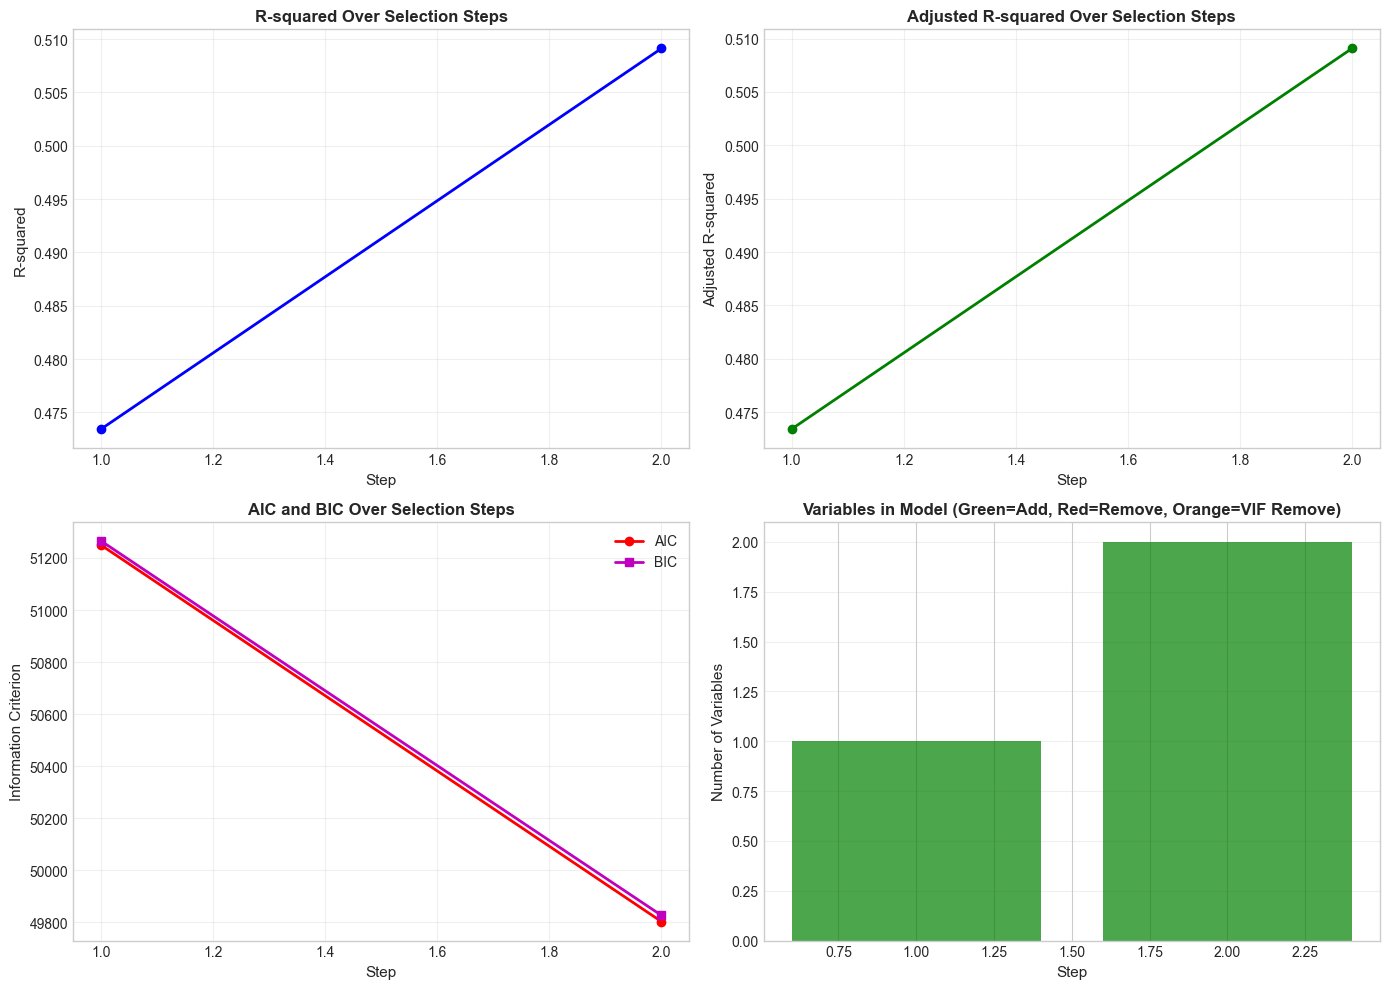

In [18]:
# Visualize Forward Selection Results

model_forward.plot_selection_history()

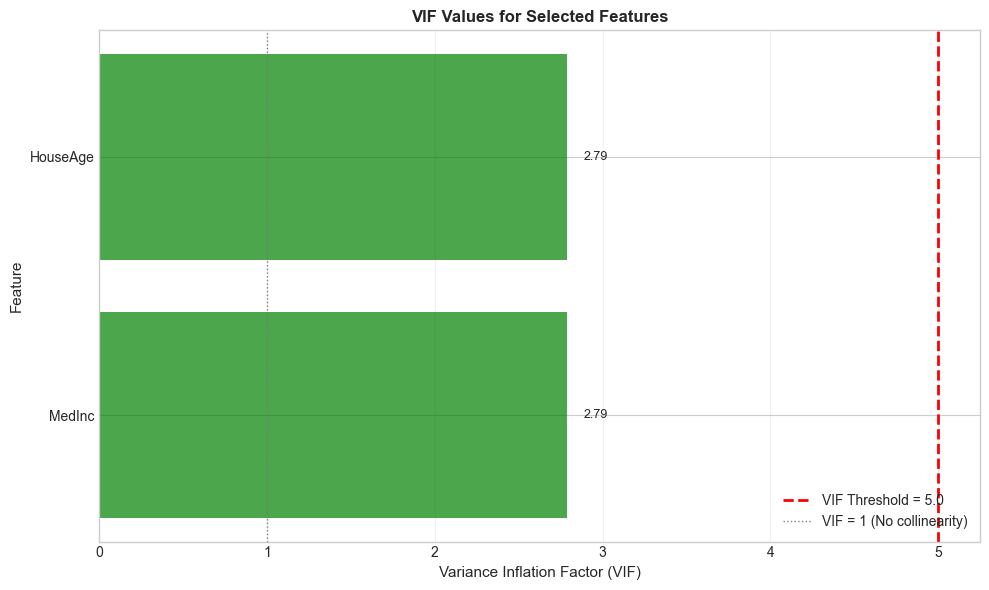

In [19]:
# Plot VIF values for selected features

model_forward.plot_vif()

### 7.2 Backward Elimination with VIF

In [20]:
# Backward Elimination with VIF constraint

model_backward = StepwiseVIFRegression(
    method='backward',
    p_enter=0.05,
    p_remove=0.10,
    vif_threshold=5.0,
    verbose=1
)

model_backward.fit(X, y)


BACKWARD ELIMINATION
p_remove=0.1, vif_threshold=5.0

Step 1: Removing high VIF variables...
  VIF Removal: Longitude (VIF=633.71)
  VIF Removal: AveRooms (VIF=42.19)
  VIF Removal: Latitude (VIF=21.92)

Step 2: Backward elimination based on p-values...
Iteration 1:
  No variable removed. Stopping.

Final selected features (5): ['MedInc', 'HouseAge', 'AveBedrms', 'Population', 'AveOccup']


In [21]:
# Display Backward Elimination Results

print(model_backward.summary())

STEPWISE REGRESSION WITH VIF - MODEL SUMMARY

Method: BACKWARD
P-value enter: 0.05
P-value remove: 0.1
VIF threshold: 5.0

Selected Features (5):
  - MedInc
  - HouseAge
  - AveBedrms
  - Population
  - AveOccup

----------------------------------------------------------------------
MODEL STATISTICS
----------------------------------------------------------------------
R-squared:          0.511998
Adjusted R-squared: 0.511880
AIC:                49688.04
BIC:                49735.65
F-statistic:        4329.7268
F p-value:          0.00e+00
Observations:       20640

----------------------------------------------------------------------
COEFFICIENTS
----------------------------------------------------------------------
Variable                     Coef      Std Err          t        P>|t|        VIF
----------------------------------------------------------------------
const                     -0.2221       0.0277     -8.022       0.0000        N/A
MedInc                     0.4336   

### 7.3 Bidirectional Stepwise Selection with VIF

In [22]:
# Bidirectional Stepwise Selection with VIF constraint

model_bidirectional = StepwiseVIFRegression(
    method='bidirectional',
    p_enter=0.05,
    p_remove=0.10,
    vif_threshold=5.0,
    verbose=1
)

model_bidirectional.fit(X, y)


BIDIRECTIONAL STEPWISE SELECTION
p_enter=0.05, p_remove=0.1, vif_threshold=5.0

Iteration 1:
  + Added: MedInc (p=0.0000)
Iteration 2:
  + Added: HouseAge (p=0.0000)
Iteration 3:
Iteration 4:
  + Added: AveRooms (p=0.0000)
Iteration 5:
Iteration 6:
  + Added: AveOccup (p=0.0000)
Iteration 7:
Iteration 8:
  Converged: No changes in last 2 iterations.

Final selected features (4): ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup']


In [23]:
# Display Bidirectional Selection Results

print(model_bidirectional.summary())

STEPWISE REGRESSION WITH VIF - MODEL SUMMARY

Method: BIDIRECTIONAL
P-value enter: 0.05
P-value remove: 0.1
VIF threshold: 5.0

Selected Features (4):
  - MedInc
  - HouseAge
  - AveRooms
  - AveOccup

----------------------------------------------------------------------
MODEL STATISTICS
----------------------------------------------------------------------
R-squared:          0.513713
Adjusted R-squared: 0.513618
AIC:                49613.40
BIC:                49653.08
F-statistic:        5449.6882
F p-value:          0.00e+00
Observations:       20640

----------------------------------------------------------------------
COEFFICIENTS
----------------------------------------------------------------------
Variable                     Coef      Std Err          t        P>|t|        VIF
----------------------------------------------------------------------
const                      0.0314       0.0220      1.428       0.1534        N/A
MedInc                     0.4433       0.0031 

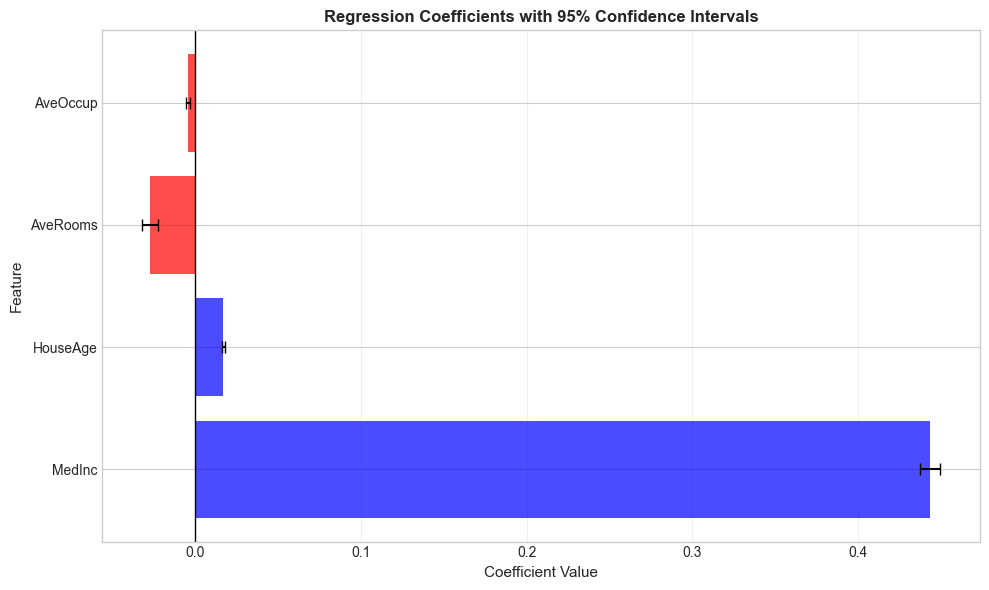

In [24]:
# Plot coefficients for bidirectional model

model_bidirectional.plot_coefficients()

### 7.4 Comparison of Methods

In [25]:
# Compare the three methods

def compare_models(models_dict):
    """Compare multiple fitted StepwiseVIFRegression models."""
    results = []
    
    for name, model in models_dict.items():
        if model.model_ is not None:
            metrics = get_model_metrics(model.model_)
            max_vif = model.vif_final_['VIF'].max() if not model.vif_final_.empty else np.nan
            results.append({
                'Method': name,
                'N_Features': len(model.selected_features_),
                'R2': metrics['r2'],
                'Adj_R2': metrics['adj_r2'],
                'AIC': metrics['aic'],
                'BIC': metrics['bic'],
                'Max_VIF': max_vif,
                'Features': ', '.join(model.selected_features_)
            })
    
    return pd.DataFrame(results)

# Create comparison
models = {
    'Forward': model_forward,
    'Backward': model_backward,
    'Bidirectional': model_bidirectional
}

comparison_df = compare_models(models)
print("Model Comparison")
print("=" * 100)
print(comparison_df[['Method', 'N_Features', 'R2', 'Adj_R2', 'AIC', 'BIC', 'Max_VIF']].to_string(index=False))
print()
print("Selected Features by Method:")
print("-" * 100)
for _, row in comparison_df.iterrows():
    print(f"{row['Method']}: {row['Features']}")

Model Comparison
       Method  N_Features       R2   Adj_R2          AIC          BIC  Max_VIF
      Forward           2 0.509120 0.509072 49803.430864 49827.235822 2.787080
     Backward           5 0.511998 0.511880 49688.036339 49735.646256 4.263506
Bidirectional           4 0.513713 0.513618 49613.400513 49653.075444 4.990004

Selected Features by Method:
----------------------------------------------------------------------------------------------------
Forward: MedInc, HouseAge
Backward: MedInc, HouseAge, AveBedrms, Population, AveOccup
Bidirectional: MedInc, HouseAge, AveRooms, AveOccup


In [26]:
# View iteration history for bidirectional model

print("Iteration History (Bidirectional)")
print("=" * 80)
history_df = model_bidirectional.get_iteration_history()
if not history_df.empty:
    display_cols = ['step', 'action', 'variable', 'p_value', 'vif', 'r2', 'adj_r2', 'n_variables']
    print(history_df[display_cols].to_string(index=False))
else:
    print("No iterations recorded.")

Iteration History (Bidirectional)
 step action variable      p_value      vif       r2   adj_r2  n_variables
    1    add   MedInc 0.000000e+00 1.000000 0.473447 0.473422            1
    2    add HouseAge 0.000000e+00 2.787080 0.509120 0.509072            2
    3    add AveRooms 3.485426e-29 4.987324 0.512102 0.512031            3
    4    add AveOccup 1.452390e-16 1.084193 0.513713 0.513618            4


### 7.5 Making Predictions

Prediction Metrics (Bidirectional Model)
R-squared:  0.513713
RMSE:       0.804684
MAE:        0.598917


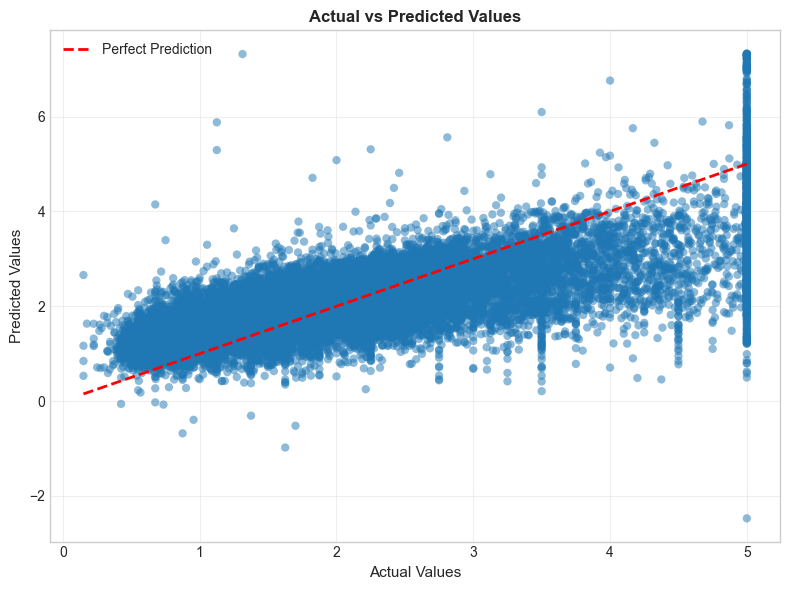

In [27]:
# Make predictions using the best model

# Use bidirectional model for predictions
y_pred = model_bidirectional.predict(X)

# Calculate prediction metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("Prediction Metrics (Bidirectional Model)")
print("=" * 40)
print(f"R-squared:  {r2:.6f}")
print(f"RMSE:       {rmse:.6f}")
print(f"MAE:        {mae:.6f}")

# Plot actual vs predicted
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y, y_pred, alpha=0.5, edgecolors='none')
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Values', fontsize=11)
ax.set_ylabel('Predicted Values', fontsize=11)
ax.set_title('Actual vs Predicted Values', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Testing with Synthetic Data (Multicollinearity Example)

Let's test the algorithm with synthetic data that has known multicollinearity to verify the VIF-based selection is working correctly.

In [28]:
# Create synthetic data with known multicollinearity

X_synth, y_synth = create_synthetic_data(n_samples=500, random_state=42)

print("\nInitial VIF for Synthetic Data:")
print("-" * 40)
synth_vif = calculate_vif(X_synth)
print(synth_vif.sort_values('VIF', ascending=False).to_string(index=False))

Created synthetic dataset with multicollinearity
Features: ['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Corr_with_F0', 'Corr_with_F1', 'Corr_with_F0_F1', 'Feature_8', 'Feature_9']
Shape: (500, 10)
True informative features: Feature_0, Feature_1, Feature_2, Feature_3, Feature_4
Correlated features: Corr_with_F0, Corr_with_F1, Corr_with_F0_F1

Initial VIF for Synthetic Data:
----------------------------------------
        feature        VIF
      Feature_0 101.555967
   Corr_with_F0  77.161237
      Feature_1  62.587308
Corr_with_F0_F1  51.125206
   Corr_with_F1  32.849165
      Feature_2   1.018636
      Feature_8   1.015482
      Feature_4   1.011430
      Feature_9   1.008255
      Feature_3   1.007687


In [29]:
# Run stepwise regression with VIF on synthetic data

model_synth = StepwiseVIFRegression(
    method='bidirectional',
    p_enter=0.05,
    p_remove=0.10,
    vif_threshold=5.0,
    verbose=1
)

model_synth.fit(X_synth, y_synth)
print("\n" + model_synth.summary())


BIDIRECTIONAL STEPWISE SELECTION
p_enter=0.05, p_remove=0.1, vif_threshold=5.0

Iteration 1:
  + Added: Feature_0 (p=0.0000)
Iteration 2:
  + Added: Feature_1 (p=0.0000)
Iteration 3:
  + Added: Feature_2 (p=0.0000)
Iteration 4:
  + Added: Feature_3 (p=0.0000)
Iteration 5:
  + Added: Feature_4 (p=0.0000)
Iteration 6:
Iteration 7:
  Converged: No changes in last 2 iterations.

Final selected features (5): ['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4']

STEPWISE REGRESSION WITH VIF - MODEL SUMMARY

Method: BIDIRECTIONAL
P-value enter: 0.05
P-value remove: 0.1
VIF threshold: 5.0

Selected Features (5):
  - Feature_0
  - Feature_1
  - Feature_2
  - Feature_3
  - Feature_4

----------------------------------------------------------------------
MODEL STATISTICS
----------------------------------------------------------------------
R-squared:          0.986083
Adjusted R-squared: 0.985942
AIC:                703.19
BIC:                728.48
F-statistic:        7000.1799
F 

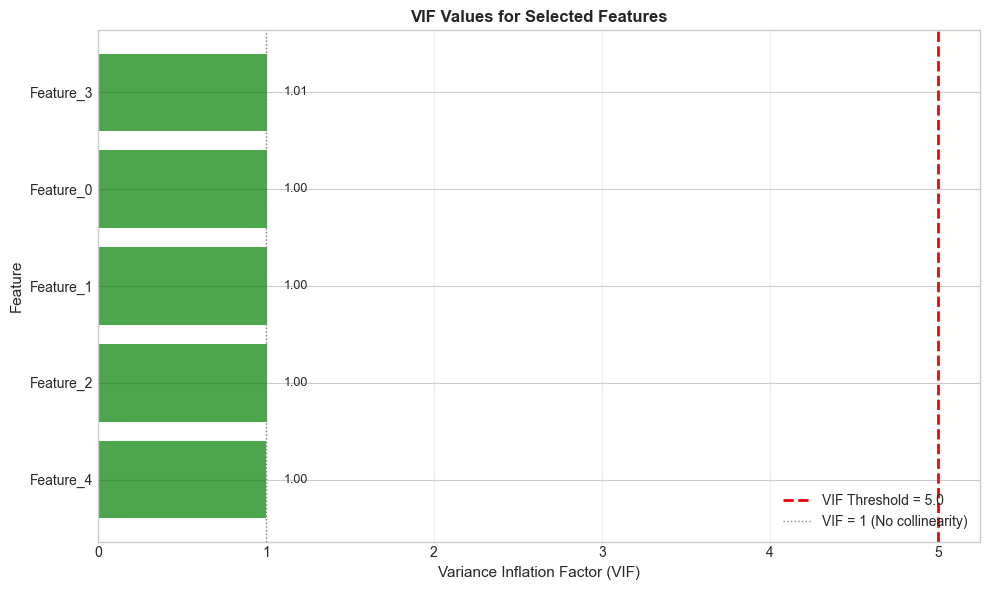

In [30]:
# Visualize VIF for synthetic data model

model_synth.plot_vif()

## 9. Conclusion

This notebook implements a comprehensive **Stepwise Regression with Joint VIF and P-Value Stopping Criterion** that combines the best features from multiple existing implementations:

### Key Features Implemented:
1. **Joint Stopping Criterion**: Variables must satisfy BOTH statistical significance (p-value < threshold) AND low multicollinearity (VIF < threshold)
2. **Three Selection Methods**: Forward, Backward, and Bidirectional stepwise selection
3. **Multiple Criteria**: Support for p-value, AIC, BIC, and Adjusted R² based selection
4. **VIF-based Multicollinearity Handling**: Iteratively removes high VIF variables
5. **Early Stopping**: Optional early stopping with patience and tolerance parameters
6. **Comprehensive Visualization**: Plots for selection history, VIF values, and coefficients
7. **Detailed Logging**: Complete iteration history with all metrics
8. **Scikit-learn Style API**: Familiar `.fit()`, `.predict()`, and `.summary()` methods

### Usage Guidelines:
- Use **Forward Selection** when starting with no variables and want to build up the model
- Use **Backward Elimination** when starting with all variables and want to reduce the model
- Use **Bidirectional Selection** for the most thorough approach that allows both addition and removal

### Recommended Thresholds:
- **p_enter**: 0.05 (standard significance level)
- **p_remove**: 0.10 (slightly relaxed to avoid removing marginally significant variables)
- **vif_threshold**: 5.0 (conservative) or 10.0 (lenient)

### References:
- Walpole, Myers, Myers (2016). Probability and Statistics for Engineers and Scientists, 9th ed.
- Strang (2006). Linear Algebra and its Applications, 4th ed.
- Medium Article: Stepwise Variation Inflation Factor by Amit Gottipati

In [31]:
# Final summary - display the statsmodels summary for the best model

print("Full statsmodels Summary for Bidirectional Model:")
print("=" * 70)
if model_bidirectional.model_ is not None:
    print(model_bidirectional.model_.summary())

Full statsmodels Summary for Bidirectional Model:
                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.514
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     5450.
Date:                Sun, 25 Jan 2026   Prob (F-statistic):               0.00
Time:                        00:27:41   Log-Likelihood:                -24802.
No. Observations:               20640   AIC:                         4.961e+04
Df Residuals:                   20635   BIC:                         4.965e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co